In [1]:
import numpy as np
EL = np.sqrt(8*4*1)/(2*np.pi**2)
EL

0.28657958412537815

(<Figure size 640x480 with 1 Axes>,
 <AxesSubplot: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

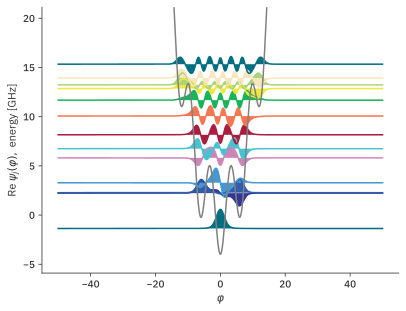

In [43]:

import scqubits

qbt = scqubits.Fluxonium(EJ = 4,EC = 1,EL = 4/20, cutoff = 110,flux = 0,truncated_dim=20)
qbt.plot_wavefunction(which = list(range(13)),phi_grid=scqubits.core.discretization.Grid1d(-50,50,400))

(<Figure size 1000x500 with 3 Axes>, (<Axes3DSubplot: >, <AxesSubplot: >))

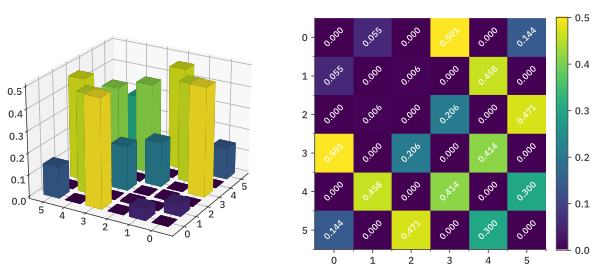

In [13]:
qbt.plot_matrixelements('n_operator',show_numbers=True)

In [3]:
import matplotlib.gridspec as gridspec

import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils_visualization import *

In [96]:


colors = [(0.7, 0.6, 0.0), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]

def plot_fluxonium_transitions(ax,matrix, energies,xlim,ylim = (2e-3,0.8) ):
    from random import random 
        
    k = len(energies)  # Assuming matrix is k x k and energies is a list of length k
                        
    label_positions = []

    def check_collision_and_direction(new_pos, existing_positions, x_threshold=1.5, y_threshold=0.1):
        for pos in existing_positions:
            dx = new_pos[0] - pos[0]
            dy = np.log10(new_pos[1]) - np.log10(pos[1])
            if abs(dx)<0.5:
                if dy < y_threshold and dy >= 0:
                    print('detected')
                    return 1
                elif dy > -1* y_threshold and dy <= 0:
                    print('detected')
                    return -1
                    
        return False


    for i in range(3):
        for j in range(k): 
            if j >i:
                freq_ij = np.abs(energies[i] - energies[j])  # Frequency of the transition
                element_ij = abs(matrix[i, j])  # Matrix element
                
                if element_ij > 3e-3:
                    ax.plot([freq_ij, freq_ij], [0, element_ij], marker='o', color='grey', markersize=4)

                if element_ij >= ylim[0]:
                    x_loc = freq_ij  #- 0.1
                    y_loc = element_ij+0.003
                    text_pos = (x_loc, y_loc)


                    if x_loc < xlim[-1] and x_loc > xlim[0] and y_loc > ylim[0] and y_loc <ylim[-1]:
                        ax.text(*(x_loc,y_loc), rf'{i}-{j}', size=9)
                        label_positions.append(text_pos)
                    else:
                        # print(f'omitted: {i}-{j}')
                        pass
    plt.text(-0.07, 1, '(a)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')

    ax.set_ylabel(r'$\langle i | \hat{n} | j \rangle$')
    # ax.set_xlabel(r'transition frequency $\omega_{ij}$')
    ax.grid(which='major', linestyle=':', linewidth='0.5', color='black')
    ax.set_xlim(xlim)
    # ax.set_yscale('log')
    # ax.set_ylim(ylim)


def plot_sweep_Er(ax,matrix, evals,Er_list,qls = [0,1,2],ylim=(-1,1),participating_transitions = None):

    num_evals =len(evals)

    if participating_transitions != None:
        for i in range(num_evals):
                for j in range(num_evals): 
                    if (i, j) not in participating_transitions and (j, i) not in participating_transitions:
                        matrix[i, j] = 0 

    for ql  in qls:
        color  = colors[ql]
        linestyle = linestyles[ql]
        shift_from_qubit_transition = []
        for Er in tqdm(Er_list, desc = "Er loop"):
            shifts = [get_shift_accurate(matrix[ql,ql2], evals[ql2], evals[ql], Er) for ql2 in range(num_evals)] 
            shift_from_qubit_transition.append(sum(shifts))
        ax.plot(Er_list, shift_from_qubit_transition, label=rf'$\chi_{ql}$',color = color, linestyle = linestyle)

    plt.text(-0.07, 1, '(b)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')
    ax.grid(which='major', linestyle=':', linewidth='0.5', color='black')
    ax.minorticks_on()
    ax.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    ax.set_xlim(Er_list[0],Er_list[-1])
    ax.set_ylim(ylim[0],ylim[1])
    
    ax.set_xlabel(rf'$\omega_r$')
    ax.set_ylabel(r'$\chi_{j}$')
    ax.legend(loc = 'upper left')

# $\chi_0$ pole at the two crossings

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 74056.03it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_38063/172430955.py: 13

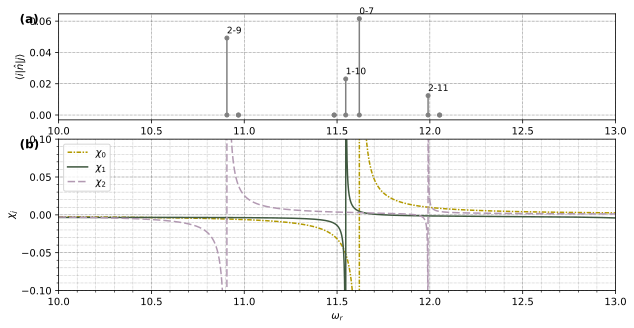

In [25]:



n_evals = 20

qbt = scqubits.Fluxonium(EJ = 4,EC = 1,EL = 4/18.8, cutoff = 110,flux = 0,truncated_dim=20)
eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list = np.linspace(10,13,int(1e4))

fig = plt.figure(figsize=(10, 5)) 
gs = gridspec.GridSpec(2, 1, height_ratios=[0.7, 1], hspace=0.15)
plot_fluxonium_transitions(plt.subplot(gs[0]), elements, eigenvals,xlim = (Er_list[0],Er_list[-1]))
plot_sweep_Er(plt.subplot(gs[1]), elements,eigenvals,Er_list,qls = [0,1,2],ylim=(-0.1,0.1))

plt.tight_layout()
plt.show()

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 74692.08it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_38063/2282056006.py: 13

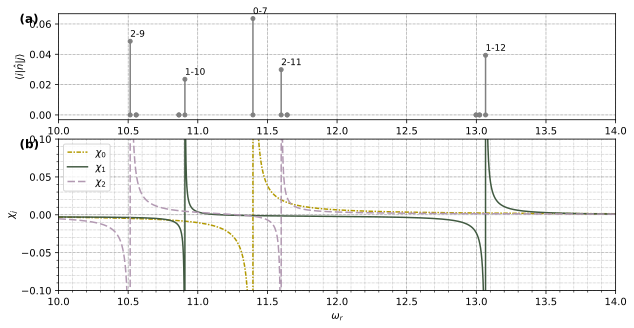

In [26]:
n_evals = 20

qbt = scqubits.Fluxonium(EJ = 4,EC = 1,EL = 4/20.2, cutoff = 110,flux = 0,truncated_dim=20)
eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list = np.linspace(10,14,int(1e4))

fig = plt.figure(figsize=(10, 5)) 
gs = gridspec.GridSpec(2, 1, height_ratios=[0.7, 1], hspace=0.15)
plot_fluxonium_transitions(plt.subplot(gs[0]), elements, eigenvals,xlim = (Er_list[0],Er_list[-1]))
plot_sweep_Er(plt.subplot(gs[1]), elements,eigenvals,Er_list,qls = [0,1,2],ylim=(-0.1,0.1))

plt.tight_layout()
plt.show()

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 74032.37it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_38063/3846382183.py: 17

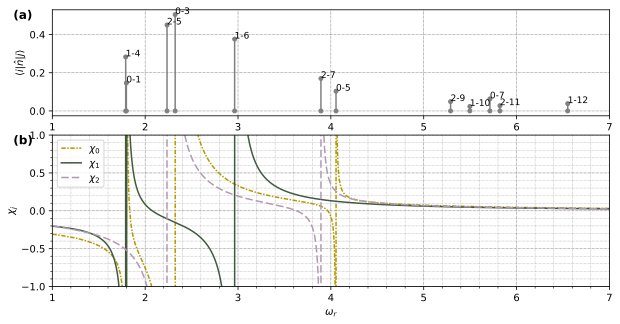

In [99]:



n_evals = 20

qbt = scqubits.Fluxonium(EJ = 2,EC = 0.5,EL = 2/20, cutoff = 110,flux = 0,truncated_dim=20)
eigenvals = qbt.eigenvals(n_evals)
elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
Er_list = np.linspace(1,5,int(1e4))

fig = plt.figure(figsize=(10, 5)) 
gs = gridspec.GridSpec(2, 1, height_ratios=[0.7, 1], hspace=0.15)
plot_fluxonium_transitions(plt.subplot(gs[0]), elements, eigenvals,xlim = (Er_list[0],Er_list[-1]))
plot_sweep_Er(plt.subplot(gs[1]), elements,eigenvals,Er_list,qls = [0,1,2],ylim=(-1,1),
            #   participating_transitions = [(0,7),(1,10),(1,12),(2,9),(2,11)])
            participating_transitions = [(0,1),(0,3),(0,5),
                                        (1,0),(1,2),(1,4),(1,6),
                                         (2,3),(2,5),(2,7)])

plt.tight_layout()
plt.show()

(<Figure size 1000x500 with 3 Axes>, (<Axes3DSubplot: >, <AxesSubplot: >))

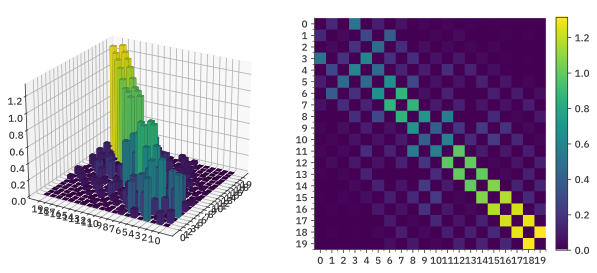

In [70]:
qbt.plot_matrixelements('n_operator',evals_count=20)

(<Figure size 640x480 with 1 Axes>,
 <AxesSubplot: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

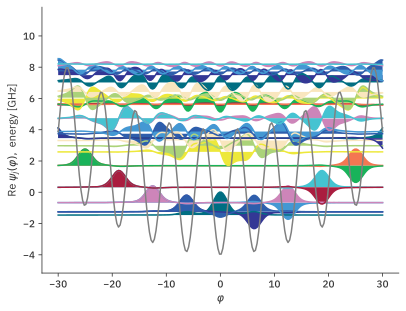

In [95]:
qbt = scqubits.Fluxonium(EJ = 4,EC = 1,EL = 0.01, cutoff = 110,flux = 0,truncated_dim=20)
qbt.plot_wavefunction(which=list(range(30)),phi_grid=scqubits.core.discretization.Grid1d(-30,30,200))

 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_38063/2222508219.py: 166

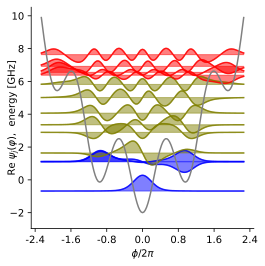

In [100]:
qbt = scqubits.Fluxonium(EJ = 2,EC = 0.5,EL = 2/20.2, cutoff = 110,flux = 0,truncated_dim=20)



from scqubits.settings import matplotlib_settings
import matplotlib as mpl
from matplotlib.axes import Axes
from scqubits.utils.plot_utils import _extract_kwargs_options
from numpy import ndarray
from scqubits.utils.misc import InfoBar, process_which
import scqubits.core.constants as constants
from scqubits.utils.spectrum_utils import (
    get_matrixelement_table,
    order_eigensystem,
    recast_esys_mapdata,
    standardize_sign,
)
from scqubits.utils.plot_utils import (
    _extract_kwargs_options,
    _process_options,
    add_numbers_to_axes,
    color_normalize,
    plot_potential_to_axes,
    plot_wavefunction_to_axes,
    scale_wavefunctions,
)
import scqubits.utils.misc as utils

@mpl.rc_context(matplotlib_settings)
def plot_wavefunction(
    qbt,
    which = 0,
    colors = None,
    mode= "real",
    esys = None,
    phi_grid = None,
    scaling = None,
    **kwargs,
):

    wavefunc_indices = process_which(which, qbt.truncated_dim)

    if esys is None:
        evals_count = max(wavefunc_indices) + 1
        esys = qbt.eigensys(evals_count=evals_count)
        evals, _ = esys
    else:
        evals, _ = esys

    if colors == None:
        colors = ['grey' for _ in range(len(evals))]

    energies = evals[list(wavefunc_indices)]

    phi_grid = phi_grid or qbt._default_grid
    potential_vals = qbt.potential(phi_grid.make_linspace())

    amplitude_modifier = constants.MODE_FUNC_DICT[mode]
    wavefunctions = []
    for wavefunc_index in wavefunc_indices:
        phi_wavefunc = qbt.wavefunction(
            esys, which=wavefunc_index, phi_grid=phi_grid
        )
        phi_wavefunc.amplitudes = standardize_sign(phi_wavefunc.amplitudes)
        phi_wavefunc.amplitudes = amplitude_modifier(phi_wavefunc.amplitudes)
        wavefunctions.append(phi_wavefunc)

    fig_ax = kwargs.get("fig_ax") or plt.subplots()
    kwargs["fig_ax"] = fig_ax
    kwargs = {
        **qbt.wavefunction1d_defaults(
            mode, evals, wavefunc_count=len(wavefunc_indices)  # type:ignore
        ),
        **kwargs,
    }
    # in merging the dictionaries in the previous line: if any duplicates,
    # later ones survive

    wavefunction1d(
        wavefunctions,
        potential_vals=potential_vals,  # type:ignore
        offset=energies,
        scaling=scaling,
        colors = colors,
        **kwargs,
    )
    return fig_ax

@mpl.rc_context(matplotlib_settings)
def wavefunction1d(
    wavefuncs,
    potential_vals,
    offset,
    scaling,
    colors,
    **kwargs,
):

    fig, axes = kwargs.get("fig_ax") or plt.subplots()

    offset_list = utils.to_list(offset)
    wavefunc_list = utils.to_list(wavefuncs)
    wavefunc_list = scale_wavefunctions(wavefunc_list, potential_vals, scaling)

    for wavefunction, energy_offset,color in zip(wavefunc_list, offset_list,colors):
        plot_wavefunction_to_axes(axes, wavefunction, energy_offset,color=color, **kwargs)

    x_vals = wavefunc_list[0].basis_labels
    plot_potential_to_axes(axes, x_vals, potential_vals, offset_list, **kwargs)

    _process_options(fig, axes, **kwargs)
    return fig, axes



@mpl.rc_context(matplotlib_settings)
def plot_wavefunction_to_axes(
    axes,
      wavefunction,
      energy_offset,
      color,
        **kwargs
) -> None:
    x_vals = wavefunction.basis_labels
    y_vals = energy_offset + wavefunction.amplitudes
    offset_vals = [energy_offset] * len(x_vals)

    axes.plot(x_vals, y_vals,color = color, alpha=0.8, **_extract_kwargs_options(kwargs, "plot"))
    axes.fill_between(
        x_vals, y_vals, offset_vals,color = color, alpha=0.5,where=(y_vals != offset_vals), interpolate=True
    )


@mpl.rc_context(matplotlib_settings)
def plot_potential_to_axes(
    axes: Axes,
    x_vals: ndarray,
    potential_vals: Union[ndarray, List[float]],
    offset_list: Union[ndarray, List[float]],
    **kwargs,
) -> None:
    y_min = np.min(potential_vals)
    y_max = np.max(offset_list)
    y_range = y_max - y_min

    y_max += 0.3 * y_range
    y_min = np.min(potential_vals) - 0.1 * y_range
    axes.set_ylim([y_min, y_max])

    axes.plot(
        x_vals, potential_vals, color="gray", **_extract_kwargs_options(kwargs, "plot")
    )

fig, ax = plt.subplots(figsize=(4,4))

fig, ax = plot_wavefunction( qbt, which=list(range(13)),colors = ['blue','blue','blue',
                                                                   'olive','olive','olive','olive', 'olive','olive',
                                                                   'red','red','red','red'
                                                                  ],
                                                                  fig_ax =(fig, ax ) )
ax.yaxis.set_label_coords(-0.06, 0.5)

current_ticks = ax.get_xticks()
modified_ticks = current_ticks /(2* np.pi)
# ax.set_xticks(modified_ticks)
ax.set_xticklabels([f'{val:.1f}' for val in modified_ticks])

ax.set_xlabel(r"$\phi/2\pi$")

fig.savefig('wavefuncs.pdf')
